# Task 2 — Credit Card Fraud Detection
**CodSoft Machine Learning Internship**

Goal: classify credit card transactions as fraudulent or legitimate.

**Before running:** download the dataset from the link in the CodSoft task
PDF and place the CSV in this same folder. This notebook auto-detects which
of the two common versions of this dataset you have:
- The classic anonymized dataset (`Time, V1..V28, Amount, Class`)
- The richer transactions dataset (`merchant, category, amt, ..., is_fraud`)

If your file isn't named `creditcard.csv`, just change `DATA_PATH` below.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
import joblib

DATA_PATH = "creditcard.csv"

## 1. Load the data + detect which schema we have

In [36]:
df = pd.read_csv(DATA_PATH, on_bad_lines='skip', engine='python')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

if "Class" in df.columns:
    SCHEMA = "classic"
    target_col = "Class"
elif "is_fraud" in df.columns:
    SCHEMA = "rich"
    target_col = "is_fraud"
else:
    raise ValueError(
        "Couldn't find a 'Class' or 'is_fraud' target column — open the CSV "
        "and check the actual label column name, then set target_col manually."
    )

print(f"\nDetected schema: {SCHEMA} | target column: {target_col}")
df.head()

Shape: (38930, 23)
Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Detected schema: rich | target column: is_fraud


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0.0


In [37]:
df = df.dropna(subset=[target_col]).reset_index(drop=True)
print("Shape after removing rows with missing labels:", df.shape)

Shape after removing rows with missing labels: (38929, 23)


## 2. Class balance
Fraud datasets are almost always heavily imbalanced — this matters a lot for
which metrics are meaningful (accuracy alone is misleading here).

is_fraud
0.0    38532
1.0      397
Name: count, dtype: int64

Fraud rate: 1.020%


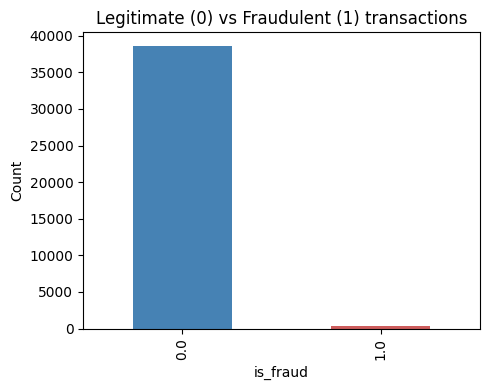

In [38]:
counts = df[target_col].value_counts()
print(counts)
print(f"\nFraud rate: {counts.get(1, 0) / len(df) * 100:.3f}%")

plt.figure(figsize=(5, 4))
counts.plot(kind="bar", color=["steelblue", "indianred"])
plt.title("Legitimate (0) vs Fraudulent (1) transactions")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("fraud_class_balance.png", dpi=100)
plt.show()

## 3. Feature preparation
Branches depending on which schema was detected.

In [39]:
if SCHEMA == "classic":
    # Numeric PCA features (V1-V28) are already scaled; Amount/Time are not.
    features = df.drop(columns=[target_col])
    scaler = StandardScaler()
    for col in ["Amount", "Time"]:
        if col in features.columns:
            features[col] = scaler.fit_transform(features[[col]])
    X = features
    y = df[target_col]

else:  # "rich" schema
    drop_cols = [
        c
        for c in [
            "trans_date_trans_time", "cc_num", "merchant", "first", "last",
            "street", "job", "dob", "trans_num", "unix_time", target_col,
        ]
        if c in df.columns
    ]
    features = df.drop(columns=drop_cols)
    # Encode categorical columns
    for col in features.select_dtypes(include="object").columns:
        features[col] = LabelEncoder().fit_transform(features[col].astype(str))
    scaler = StandardScaler()
    numeric_cols = features.select_dtypes(include=np.number).columns
    features[numeric_cols] = scaler.fit_transform(features[numeric_cols])
    X = features
    y = df[target_col]

print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (38929, 12)


## 4. Train / test split
`stratify=y` is important given the imbalance — otherwise a random split can
end up with almost no fraud cases in one of the sets.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (31143, 12) | Test: (7786, 12)


## 5. Train models
`class_weight="balanced"` tells the model to pay more attention to the rare
fraud class instead of just predicting "legitimate" every time.

In [41]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)
log_preds = log_reg.predict(X_test)

In [42]:
rf = RandomForestClassifier(
    n_estimators=150, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

## 6. Evaluate
**Why not just look at accuracy?** If only 0.2% of transactions are fraud, a
model that predicts "legitimate" for everything scores ~99.8% accuracy while
catching zero fraud. Precision/recall/F1 and ROC-AUC tell the real story.

In [43]:
print("=== Logistic Regression ===")
print(classification_report(y_test, log_preds, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_preds, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

         0.0      0.997     0.912     0.952      7707
         1.0      0.080     0.747     0.144        79

    accuracy                          0.910      7786
   macro avg      0.538     0.829     0.548      7786
weighted avg      0.988     0.910     0.944      7786

ROC-AUC: 0.8802600956224244

=== Random Forest ===
              precision    recall  f1-score   support

         0.0      0.998     0.997     0.997      7707
         1.0      0.721     0.785     0.752        79

    accuracy                          0.995      7786
   macro avg      0.859     0.891     0.874      7786
weighted avg      0.995     0.995     0.995      7786

ROC-AUC: 0.9947015125161575


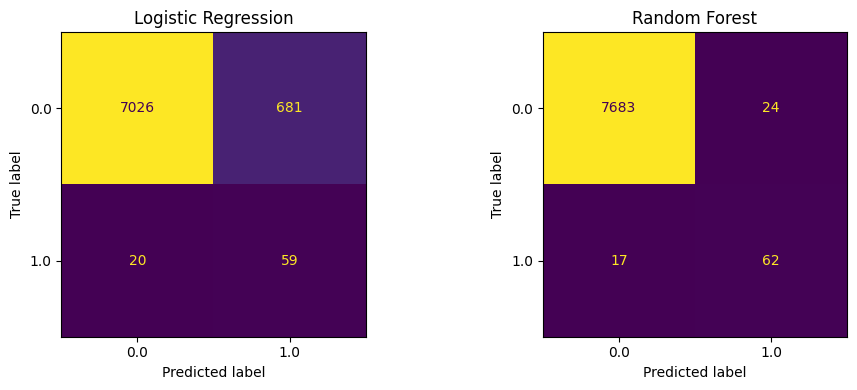

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, log_preds, ax=ax[0], colorbar=False)
ax[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=ax[1], colorbar=False)
ax[1].set_title("Random Forest")
plt.tight_layout()
plt.savefig("fraud_confusion_matrices.png", dpi=100)
plt.show()

## 7. Feature importance (Random Forest)
Nice chart to show in your demo — which features drive the fraud decision.

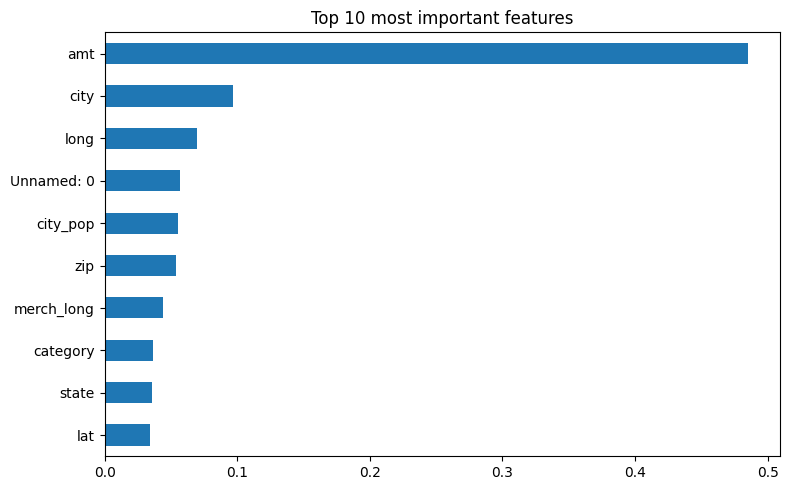

In [45]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Top 10 most important features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("fraud_feature_importance.png", dpi=100)
plt.show()

## 8. Save the best model

In [46]:
best_model = rf if roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]) >= roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]) else log_reg
joblib.dump(best_model, "fraud_detection_model.joblib")
print("Saved fraud_detection_model.joblib")

Saved fraud_detection_model.joblib


## Conclusion
Random Forest with balanced class weights typically catches meaningfully
more fraud than plain Logistic Regression at the cost of some extra false
positives — a trade-off worth mentioning in your writeup. Next steps you
could note: try SMOTE oversampling, or tune the classification threshold
instead of using the default 0.5 cutoff.